Folders ready
  TITANIC EXPLORATORY DATA ANALYSIS
✅ All libraries imported successfully!

Dataset loaded successfully!
   Rows    : 891
   Columns : 12

────────────────────────────────────────────────────────────
COLUMN REFERENCE:
────────────────────────────────────────────────────────────
  PassengerId     → Unique ID for each passenger
  Survived        → Target → 0 = Died, 1 = Survived
  Pclass          → Ticket class → 1=First, 2=Second, 3=Third
  Name            → Full name of passenger
  Sex             → Gender (male / female)
  Age             → Age in years
  SibSp           → No. of siblings/spouses aboard
  Parch           → No. of parents/children aboard
  Ticket          → Ticket number
  Fare            → Passenger fare paid (£)
  Cabin           → Cabin number
  Embarked        → Port of embarkation (S/C/Q)

────────────────────────────────────────────────────────────
FIRST 5 ROWS:
────────────────────────────────────────────────────────────
   PassengerId  Survived  P

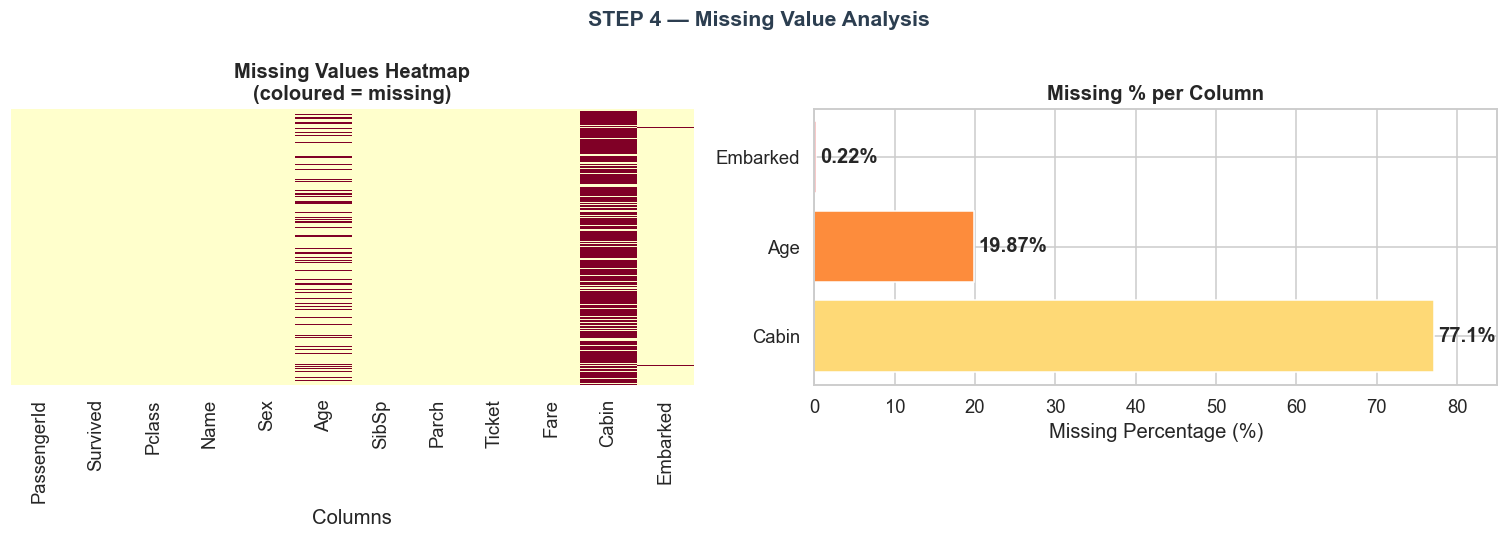


💡 Explanation:
   • Cabin  : 77.1% missing → NOT useful → will be DROPPED
   • Age    : 19.9% missing → Fill with MEDIAN age
   • Embarked: 0.2% missing → Fill with MODE (most common = 'S')

────────────────────────────────────────────────────────────
DUPLICATE RECORDS: 0
────────────────────────────────────────────────────────────
   Shape before: (891, 12)
✅ No duplicate rows found. Dataset is clean on this front.

────────────────────────────────────────────────────────────
DATA CLEANING & PREPROCESSING:
────────────────────────────────────────────────────────────
✅ 6a. Dropped 'Cabin' column (77.1% missing)
✅ 6b. Dropped 'Name' & 'Ticket' (not useful for analysis)
✅ 6c. Filled 177 missing Age values with median (28.0)
✅ 6d. Filled missing 'Embarked' values with mode ('S')
✅ 6e. Encoded 'Sex' → male=0, female=1
✅ 6f. Encoded 'Embarked' → S=0, C=1, Q=2
✅ 6g. Created 'FamilySize' = SibSp + Parch + 1
✅ 6h. Created 'IsAlone' = 1 if alone, 0 if with family
✅ 6i. Created 'AgeGroup' bins:

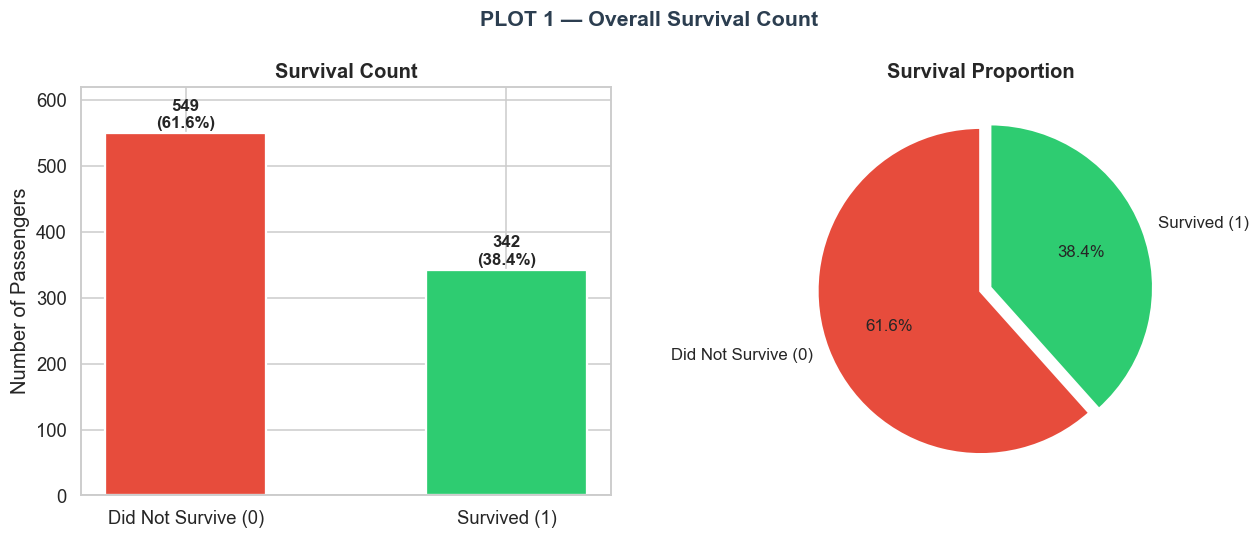


📌 PLOT 1 — FINDING:
   Only 38.4% survived. 61.6% did NOT survive.
   The Titanic disaster claimed the majority of passengers on board.


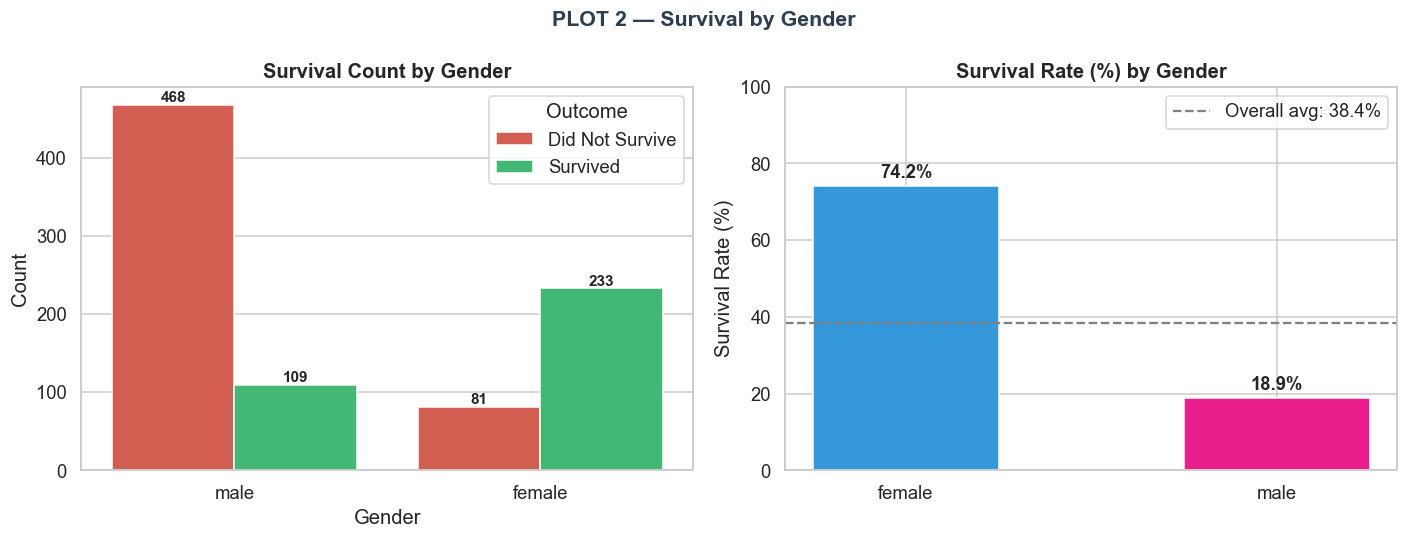


📌 PLOT 2 — FINDING:
   Female survival rate : 74.2%
   Male   survival rate : 18.9%
   Women were ~4× more likely to survive than men.
   This reflects the 'women and children first' evacuation policy.


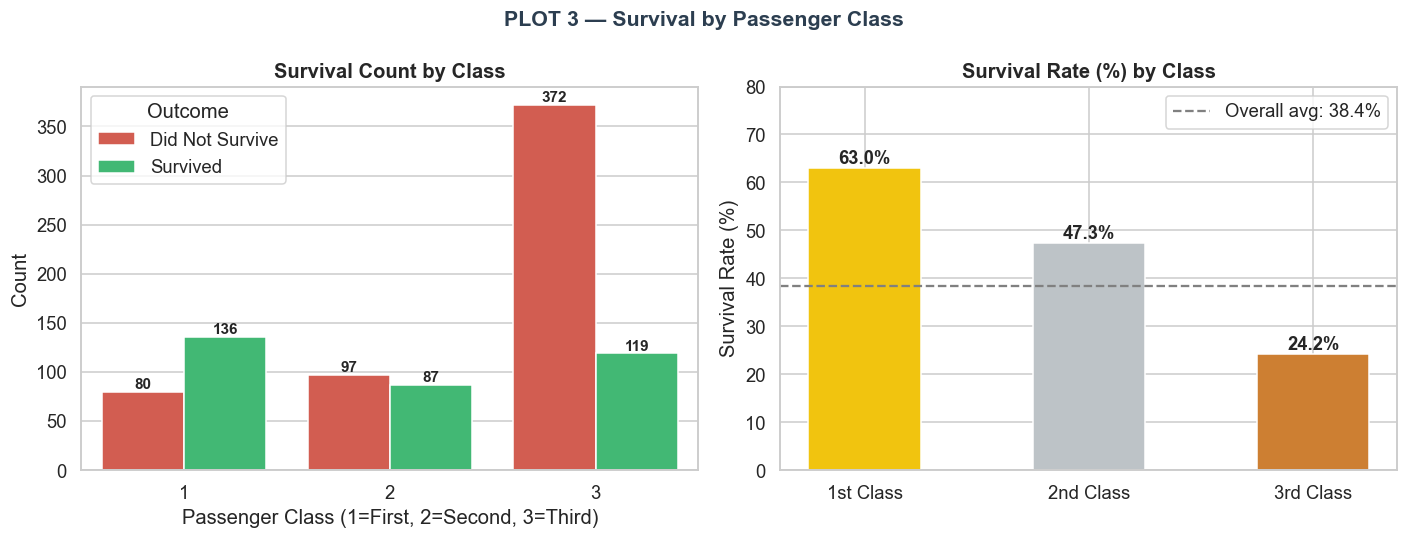


📌 PLOT 3 — FINDING:
   Class 1: 63.0% survival rate
   Class 2: 47.3% survival rate
   Class 3: 24.2% survival rate
   1st class had 2.6× the survival rate of 3rd class.
   Cabin location (upper decks = 1st class) gave faster lifeboat access.


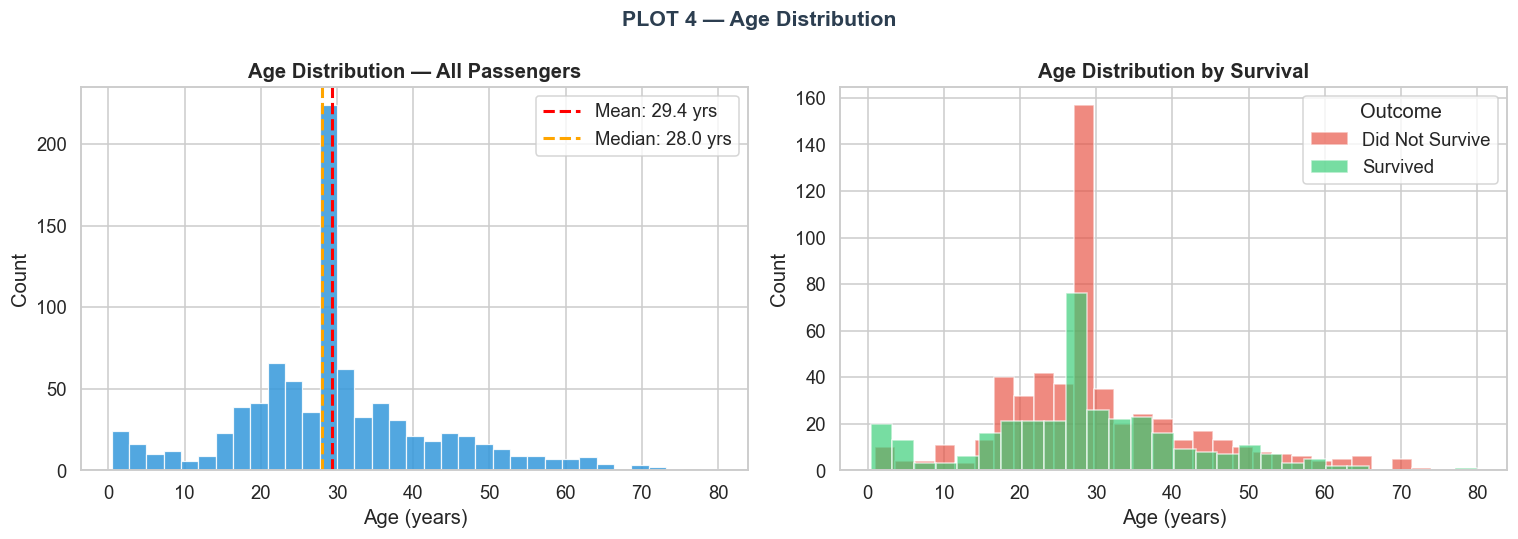


📌 PLOT 4 — FINDING:
   Average age     : 29.4 years
   Median age      : 28.0 years
   Youngest        : 0.4 years
   Oldest          : 80.0 years
   Children (0–12) had higher survival; young adults (20–35) had lower.


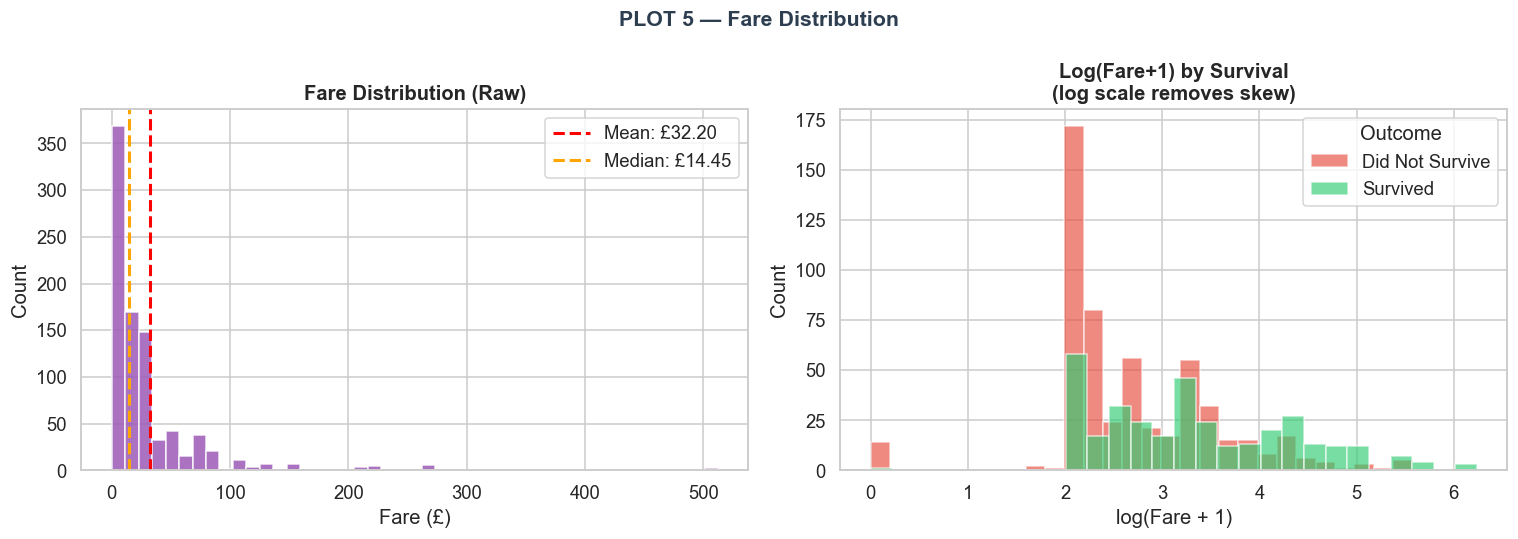


📌 PLOT 5 — FINDING:
   Min fare         : £0.00
   Median fare      : £14.45
   Mean fare        : £32.20
   Max fare         : £512.33
   Survivors avg    : £48.40
   Non-survivors avg: £22.12
   Survivors paid ~2× more — fare is a strong proxy for social class.


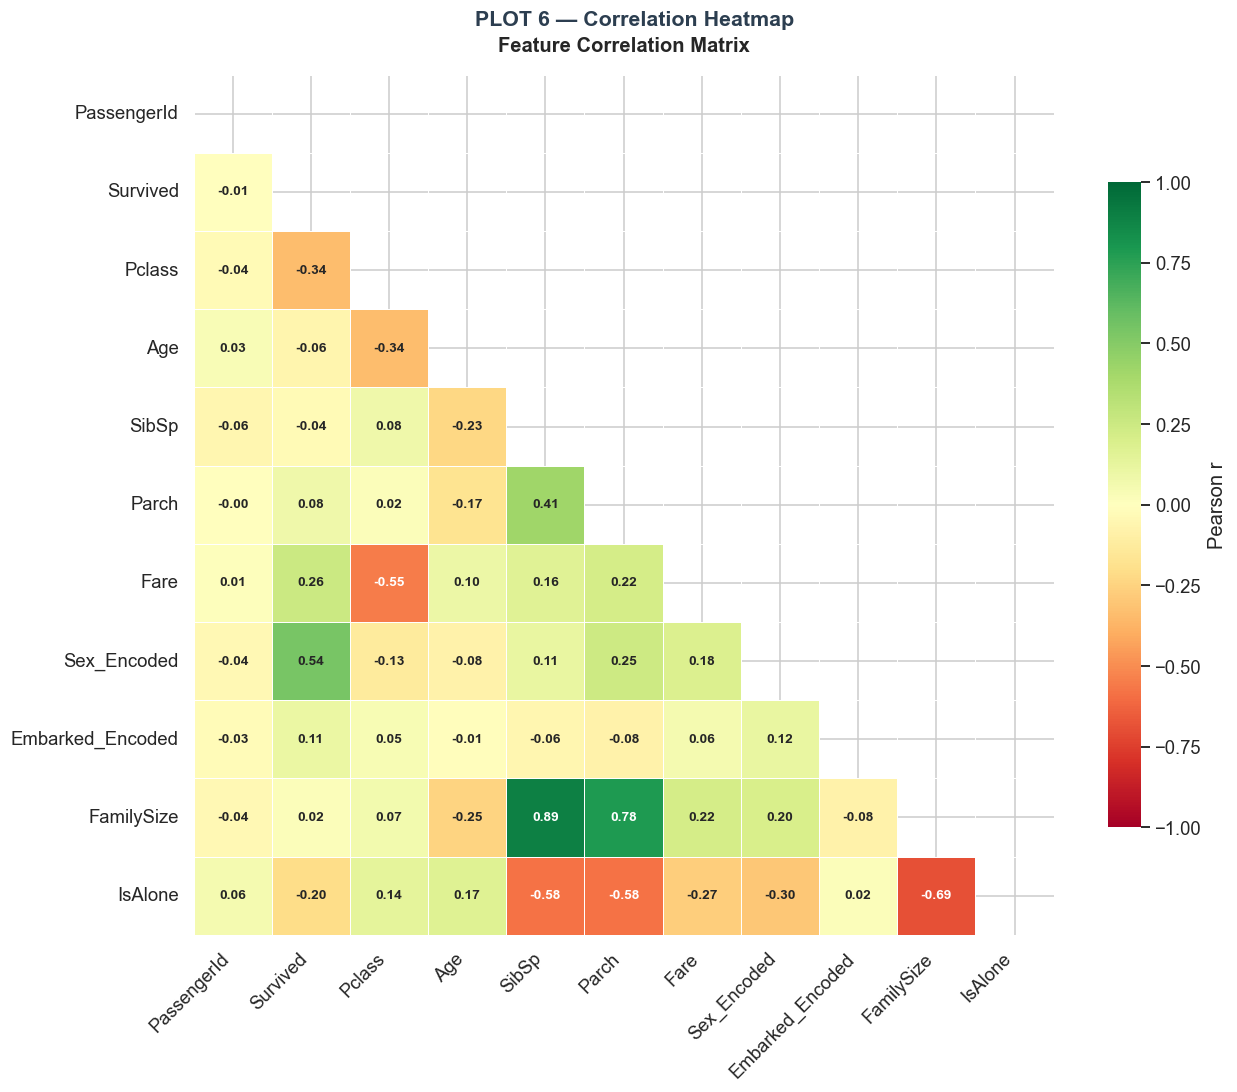


Top Features Correlated With Survival:
Survived            1.00
Sex_Encoded         0.54
Pclass             -0.34
Fare                0.26
IsAlone            -0.20
Embarked_Encoded    0.11
Parch               0.08
Age                -0.06
SibSp              -0.04
FamilySize          0.02
PassengerId        -0.01
Name: Survived, dtype: float64

📌 PLOT 6 — FINDING (correlations with 'Survived'):
   📈 POSITIVE | Strong   | Sex_Encoded         : +0.543
   📉 NEGATIVE | Strong   | Pclass              : -0.338
   📈 POSITIVE | Moderate | Fare                : +0.257
   📉 NEGATIVE | Moderate | IsAlone             : -0.203
   📈 POSITIVE | Moderate | Embarked_Encoded    : +0.107
   📈 POSITIVE | Weak     | Parch               : +0.082
   📉 NEGATIVE | Weak     | Age                 : -0.065
   📉 NEGATIVE | Weak     | SibSp               : -0.035
   📈 POSITIVE | Weak     | FamilySize          : +0.017
   📉 NEGATIVE | Weak     | PassengerId         : -0.005


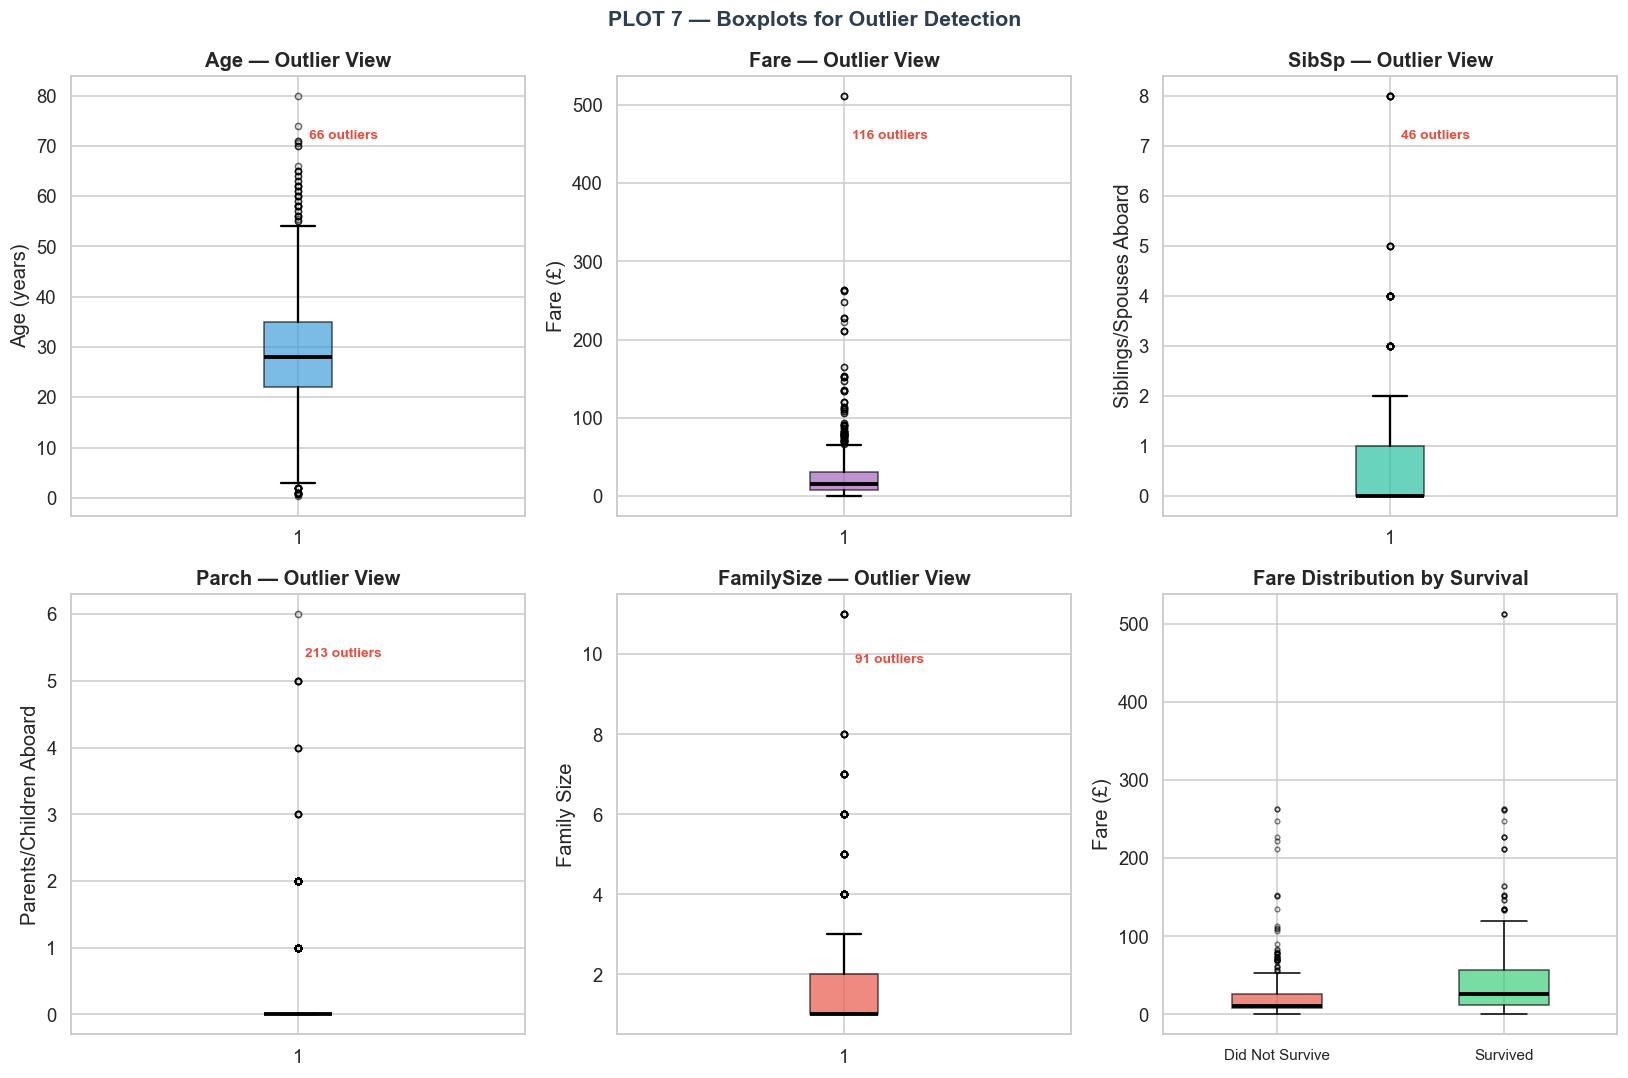


📌 PLOT 7 — FINDING:
   Age         :  66 outliers detected
   Fare        : 116 outliers detected
   SibSp       :  46 outliers detected
   Parch       : 213 outliers detected
   'Fare' outliers are GENUINE (luxury cabins) — do NOT remove them.
   They carry important information about passenger class.


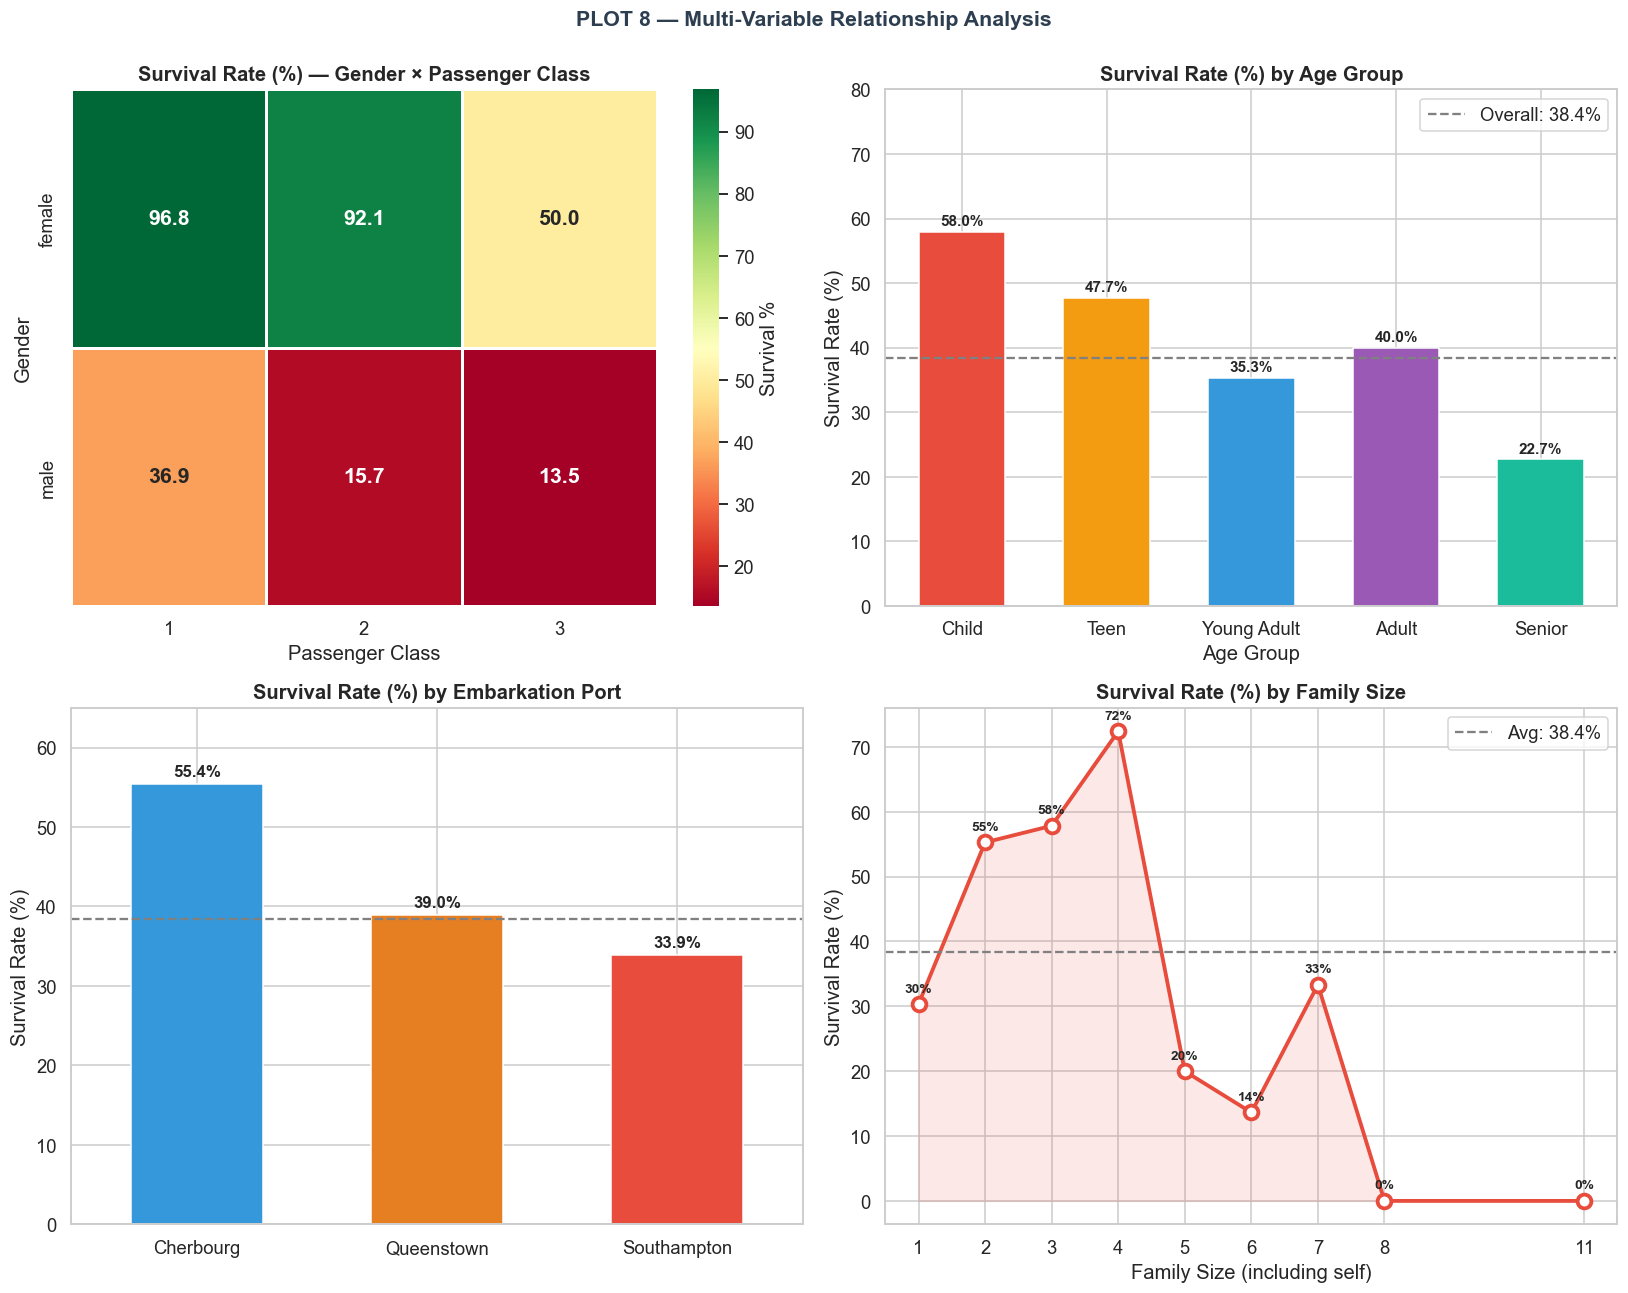


📌 PLOT 8 — FINDINGS:
   • Female 1st class: ~97% survival — highest group
   • Male   3rd class: ~14% survival — lowest group
   • Children had better survival than adults overall
   • Cherbourg port passengers had best survival (many 1st class)
   • Families of 2–4 survived better than solo travelers

  STEP 9 — VARIABLE RELATIONSHIPS & KEY PATTERNS

┌─────────────────────────────────────────────────────────────┐
│  VARIABLE          RELATIONSHIP WITH SURVIVAL               │
├─────────────────────────────────────────────────────────────┤
│  Sex          →  STRONGEST predictor. Female = 4× safer     │
│  Pclass       →  STRONG. Higher class = much better odds    │
│  Fare         →  MODERATE. Higher fare = higher class       │
│  Age          →  WEAK overall. Children slightly better     │
│  Embarked     →  INDIRECT. Cherbourg = mostly 1st class     │
│  FamilySize   →  NON-LINEAR. 2–4 members = sweet spot       │
│  SibSp/Parch  →  Weak individually; matters via FamilySize  │
└────

In [1]:


# ────────────────────────────────────────────────────────────────
# STEP 0 ▸ SETUP
# ────────────────────────────────────────────────────────────────

import os
os.makedirs("images", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("Folders ready")


# ────────────────────────────────────────────────────────────────
# STEP 1 ▸ IMPORT LIBRARIES
# ────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)

print("=" * 60)
print("  TITANIC EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print("✅ All libraries imported successfully!")

# ────────────────────────────────────────────────────────────────
# STEP 2 ▸ LOAD THE DATASET
# ────────────────────────────────────────────────────────────────

df_raw = pd.read_csv('data/titanic.csv')
df = df_raw.copy()

print(f"\nDataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n{'─'*60}")
print("COLUMN REFERENCE:")
print(f"{'─'*60}")

col_desc = {
    'PassengerId' : 'Unique ID for each passenger',
    'Survived'    : 'Target → 0 = Died, 1 = Survived',
    'Pclass'      : 'Ticket class → 1=First, 2=Second, 3=Third',
    'Name'        : 'Full name of passenger',
    'Sex'         : 'Gender (male / female)',
    'Age'         : 'Age in years',
    'SibSp'       : 'No. of siblings/spouses aboard',
    'Parch'       : 'No. of parents/children aboard',
    'Ticket'      : 'Ticket number',
    'Fare'        : 'Passenger fare paid (£)',
    'Cabin'       : 'Cabin number',
    'Embarked'    : 'Port of embarkation (S/C/Q)',
}
for col, desc in col_desc.items():
    print(f"  {col:<15} → {desc}")

print(f"\n{'─'*60}")
print("FIRST 5 ROWS:")
print(f"{'─'*60}")
print(df.head().to_string())

# ────────────────────────────────────────────────────────────────
# STEP 3 ▸ BASIC DATASET INFORMATION
# ────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("DATASET INFO:")
print(f"{'─'*60}")
df.info()

print(f"\n{'─'*60}")
print("UNIQUE VALUES PER COLUMN:")
print(f"{'─'*60}")
for col in df.columns:
    print(f"  {col:<15}: {df[col].nunique():>4} unique values")

# ────────────────────────────────────────────────────────────────
# STEP 4 ▸ MISSING VALUE ANALYSIS
# ────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("MISSING VALUE ANALYSIS:")
print(f"{'─'*60}")

miss_count = df.isnull().sum()
miss_pct = (miss_count / len(df) * 100).round(2)

miss_table = pd.DataFrame({
    'Missing Count': miss_count,
    'Missing %': miss_pct
})

def get_fix(col):
    if col == 'Age':
        return 'Fill with Median'
    elif col == 'Cabin':
        return 'Drop Column'
    elif col == 'Embarked':
        return 'Fill with Mode'
    else:
        return '—'

miss_table['Suggested Fix'] = miss_table.index.map(get_fix)
miss_table = miss_table[miss_table['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(miss_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('STEP 4 — Missing Value Analysis', fontsize=14, fontweight='bold', color='#2c3e50')

sns.heatmap(df.isnull(), cbar=False, cmap='YlOrRd', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Values Heatmap\n(coloured = missing)', fontweight='bold')
axes[0].set_xlabel('Columns')

colors = sns.color_palette("YlOrRd", len(miss_table))
bars = axes[1].barh(miss_table.index, miss_table['Missing %'], color=colors, edgecolor='white')
axes[1].set_xlabel('Missing Percentage (%)')
axes[1].set_title('Missing % per Column', fontweight='bold')
for bar, val in zip(bars, miss_table['Missing %']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[1].set_xlim(0, 85)

plt.tight_layout()
plt.savefig("images/missing_value_analysis.png", bbox_inches='tight')
plt.show()

print("\n💡 Explanation:")
print("   • Cabin  : 77.1% missing → NOT useful → will be DROPPED")
print("   • Age    : 19.9% missing → Fill with MEDIAN age")
print("   • Embarked: 0.2% missing → Fill with MODE (most common = 'S')")

# ────────────────────────────────────────────────────────────────
# STEP 5 ▸ REMOVE DUPLICATES
# ────────────────────────────────────────────────────────────────

dup_count = df.duplicated().sum()
print(f"\n{'─'*60}")
print(f"DUPLICATE RECORDS: {dup_count}")
print(f"{'─'*60}")

print(f"   Shape before: {df.shape}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"✅ {dup_count} duplicate(s) removed. New shape: {df.shape}")
else:
    print("✅ No duplicate rows found. Dataset is clean on this front.")

# ────────────────────────────────────────────────────────────────
# STEP 6 ▸ DATA CLEANING & PREPROCESSING
# ────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("DATA CLEANING & PREPROCESSING:")
print(f"{'─'*60}")

df = df.drop(columns=['Cabin'])
print("✅ 6a. Dropped 'Cabin' column (77.1% missing)")

df = df.drop(columns=['Name', 'Ticket'])
print("✅ 6b. Dropped 'Name' & 'Ticket' (not useful for analysis)")

age_median = df['Age'].median()
missing_age = df['Age'].isnull().sum()
df['Age'] = df['Age'].fillna(age_median)
print(f"✅ 6c. Filled {missing_age} missing Age values with median ({age_median:.1f})")

emb_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(emb_mode)
print(f"✅ 6d. Filled missing 'Embarked' values with mode ('{emb_mode}')")

df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})
print("✅ 6e. Encoded 'Sex' → male=0, female=1")

df['Embarked_Encoded'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print("✅ 6f. Encoded 'Embarked' → S=0, C=1, Q=2")

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print("✅ 6g. Created 'FamilySize' = SibSp + Parch + 1")

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print("✅ 6h. Created 'IsAlone' = 1 if alone, 0 if with family")

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 12, 17, 35, 60, 100],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print("✅ 6i. Created 'AgeGroup' bins: Child/Teen/Young Adult/Adult/Senior")

df['FareBand'] = pd.cut(df['Fare'],
                        bins=[-1, 10, 30, 100, 600],
                        labels=['Low', 'Medium', 'High', 'Very High'])
print("✅ 6j. Created 'FareBand' bins: Low/Medium/High/Very High")

print(f"\n📊 CLEANED DATASET SUMMARY:")
print(f"   Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Missing values : {df.isnull().sum().sum()}")
print(f"\nCleaned Dataset Preview:")
print(df.head(8).to_string())

# ────────────────────────────────────────────────────────────────
# STEP 7 ▸ DESCRIPTIVE STATISTICS
# ────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS:")
print(f"{'─'*60}")
print(df.describe().round(2).to_string())

print(f"\n{'─'*60}")
print("DESCRIPTIVE STATISTICS — CATEGORICAL COLUMNS:")
print(f"{'─'*60}")
print(df.describe(include=['object', 'category']).to_string())

print(f"\n{'─'*60}")
print("SURVIVAL BREAKDOWN:")
print(f"{'─'*60}")
surv = df['Survived'].value_counts()
print(f"  Survived       : {surv[1]:>3}  ({surv[1]/len(df)*100:.1f}%)")
print(f"  Did Not Survive: {surv[0]:>3}  ({surv[0]/len(df)*100:.1f}%)")
print(f"  Total          : {len(df):>3} passengers")

# ════════════════════════════════════════════════════════════════
# STEP 8 ▸ VISUALISATIONS
# ════════════════════════════════════════════════════════════════

# PLOT 1 ▸ SURVIVAL COUNT
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PLOT 1 — Overall Survival Count', fontsize=14, fontweight='bold', color='#2c3e50')

counts = df['Survived'].value_counts()
colors = ['#e74c3c', '#2ecc71']
labels = ['Did Not Survive (0)', 'Survived (1)']

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Survival Count', fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_ylim(0, 620)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.06),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Survival Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig("images/plot1_survival_count.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 1 — FINDING:")
print("   Only 38.4% survived. 61.6% did NOT survive.")
print("   The Titanic disaster claimed the majority of passengers on board.")

# PLOT 2 ▸ SURVIVAL BY GENDER
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PLOT 2 — Survival by Gender', fontsize=14, fontweight='bold', color='#2c3e50')

sns.countplot(data=df, x='Sex', hue='Survived',
              palette={0: '#e74c3c', 1: '#2ecc71'},
              ax=axes[0], edgecolor='white')
axes[0].set_title('Survival Count by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'], title='Outcome')
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontweight='bold', fontsize=10)

surv_sex = df.groupby('Sex')['Survived'].mean() * 100
bars = axes[1].bar(surv_sex.index, surv_sex.values,
                   color=['#3498db', '#e91e8c'],
                   edgecolor='white', width=0.5)
axes[1].set_title('Survival Rate (%) by Gender', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].axhline(df['Survived'].mean()*100, ls='--', color='gray',
                label=f'Overall avg: {df["Survived"].mean()*100:.1f}%')
axes[1].legend()
for bar, val in zip(bars, surv_sex.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("images/plot2_survival_by_gender.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 2 — FINDING:")
print(f"   Female survival rate : {df[df.Sex=='female']['Survived'].mean()*100:.1f}%")
print(f"   Male   survival rate : {df[df.Sex=='male']['Survived'].mean()*100:.1f}%")
print("   Women were ~4× more likely to survive than men.")
print("   This reflects the 'women and children first' evacuation policy.")

# PLOT 3 ▸ SURVIVAL BY PASSENGER CLASS
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PLOT 3 — Survival by Passenger Class', fontsize=14, fontweight='bold', color='#2c3e50')

sns.countplot(data=df, x='Pclass', hue='Survived',
              palette={0: '#e74c3c', 1: '#2ecc71'},
              ax=axes[0], edgecolor='white')
axes[0].set_title('Survival Count by Class', fontweight='bold')
axes[0].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'], title='Outcome')
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{int(p.get_height())}',
                         (p.get_x()+p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontweight='bold', fontsize=10)

surv_pclass = df.groupby('Pclass')['Survived'].mean() * 100
bars = axes[1].bar(['1st Class', '2nd Class', '3rd Class'],
                   surv_pclass.values,
                   color=['#f1c40f', '#bdc3c7', '#cd7f32'],
                   edgecolor='white', width=0.5)
axes[1].set_title('Survival Rate (%) by Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].axhline(df['Survived'].mean()*100, ls='--', color='gray',
                label=f'Overall avg: {df["Survived"].mean()*100:.1f}%')
axes[1].legend()
for bar, val in zip(bars, surv_pclass.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("images/plot3_survival_by_class.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 3 — FINDING:")
for cls, rate in surv_pclass.items():
    print(f"   Class {cls}: {rate:.1f}% survival rate")
print("   1st class had 2.6× the survival rate of 3rd class.")
print("   Cabin location (upper decks = 1st class) gave faster lifeboat access.")

# PLOT 4 ▸ AGE DISTRIBUTION HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PLOT 4 — Age Distribution', fontsize=14, fontweight='bold', color='#2c3e50')

axes[0].hist(df['Age'], bins=35, color='#3498db', edgecolor='white', alpha=0.85, linewidth=0.8)
axes[0].axvline(df['Age'].mean(), color='red', ls='--', lw=2, label=f'Mean: {df["Age"].mean():.1f} yrs')
axes[0].axvline(df['Age'].median(), color='orange', ls='--', lw=2, label=f'Median: {df["Age"].median():.1f} yrs')
axes[0].set_title('Age Distribution — All Passengers', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

for val, color, label in [(0, '#e74c3c', 'Did Not Survive'),
                          (1, '#2ecc71', 'Survived')]:
    axes[1].hist(df[df['Survived'] == val]['Age'], bins=28,
                 alpha=0.65, color=color, edgecolor='white', label=label)
axes[1].set_title('Age Distribution by Survival', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.savefig("images/plot4_age_distribution.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 4 — FINDING:")
print(f"   Average age     : {df['Age'].mean():.1f} years")
print(f"   Median age      : {df['Age'].median():.1f} years")
print(f"   Youngest        : {df['Age'].min():.1f} years")
print(f"   Oldest          : {df['Age'].max():.1f} years")
print("   Children (0–12) had higher survival; young adults (20–35) had lower.")

# PLOT 5 ▸ FARE DISTRIBUTION HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PLOT 5 — Fare Distribution', fontsize=14, fontweight='bold', color='#2c3e50')

axes[0].hist(df['Fare'], bins=45, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Fare'].mean(), color='red', ls='--', lw=2, label=f'Mean: £{df["Fare"].mean():.2f}')
axes[0].axvline(df['Fare'].median(), color='orange', ls='--', lw=2, label=f'Median: £{df["Fare"].median():.2f}')
axes[0].set_title('Fare Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Count')
axes[0].legend()

for val, color, label in [(0, '#e74c3c', 'Did Not Survive'),
                          (1, '#2ecc71', 'Survived')]:
    axes[1].hist(np.log1p(df[df['Survived'] == val]['Fare']),
                 bins=28, alpha=0.65, color=color,
                 edgecolor='white', label=label)
axes[1].set_title('Log(Fare+1) by Survival\n(log scale removes skew)', fontweight='bold')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.savefig("images/plot5_fare_distribution.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 5 — FINDING:")
print(f"   Min fare         : £{df['Fare'].min():.2f}")
print(f"   Median fare      : £{df['Fare'].median():.2f}")
print(f"   Mean fare        : £{df['Fare'].mean():.2f}")
print(f"   Max fare         : £{df['Fare'].max():.2f}")
print(f"   Survivors avg    : £{df[df.Survived==1]['Fare'].mean():.2f}")
print(f"   Non-survivors avg: £{df[df.Survived==0]['Fare'].mean():.2f}")
print("   Survivors paid ~2× more — fare is a strong proxy for social class.")

# PLOT 6 ▸ CORRELATION HEATMAP
numeric_cols = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp',
                'Parch', 'Fare', 'Sex_Encoded', 'Embarked_Encoded',
                'FamilySize', 'IsAlone']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('PLOT 6 — Correlation Heatmap', fontsize=14, fontweight='bold', color='#2c3e50')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.75},
            annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("images/plot6_correlation_heatmap.png", bbox_inches='tight')
plt.show()

print("\nTop Features Correlated With Survival:")
print(corr['Survived'].sort_values(key=abs, ascending=False))

print("\n📌 PLOT 6 — FINDING (correlations with 'Survived'):")
surv_corr = corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
for feat, val in surv_corr.items():
    direction = '📈 POSITIVE' if val > 0 else '📉 NEGATIVE'
    strength = 'Strong' if abs(val) > 0.3 else 'Moderate' if abs(val) > 0.1 else 'Weak'
    print(f"   {direction} | {strength:8} | {feat:<20}: {val:+.3f}")

# PLOT 7 ▸ BOXPLOTS FOR OUTLIER DETECTION
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PLOT 7 — Boxplots for Outlier Detection', fontsize=14, fontweight='bold', color='#2c3e50')
axes = axes.flatten()

plot_configs = [
    ('Age', '#3498db', 'Age (years)'),
    ('Fare', '#9b59b6', 'Fare (£)'),
    ('SibSp', '#1abc9c', 'Siblings/Spouses Aboard'),
    ('Parch', '#e67e22', 'Parents/Children Aboard'),
    ('FamilySize', '#e74c3c', 'Family Size'),
]

for i, (col, color, ylabel) in enumerate(plot_configs):
    axes[i].boxplot(df[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.65),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', color='#e74c3c', markersize=4, alpha=0.6))
    axes[i].set_title(f'{col} — Outlier View', fontweight='bold')
    axes[i].set_ylabel(ylabel)

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()

    axes[i].text(
        1.1,
        axes[i].get_ylim()[1] * 0.85,
        f'{outliers} outliers',
        ha='center',
        fontsize=9,
        color='#e74c3c',
        fontweight='bold'
    )

for val, color, pos in [(0, '#e74c3c', 0), (1, '#2ecc71', 1)]:
    axes[5].boxplot(df[df['Survived'] == val]['Fare'].dropna(),
                    positions=[pos], widths=0.4, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.65),
                    medianprops=dict(color='black', linewidth=2.5),
                    flierprops=dict(marker='o', color='gray', markersize=3, alpha=0.5))
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Did Not Survive', 'Survived'], fontsize=10)
axes[5].set_title('Fare Distribution by Survival', fontweight='bold')
axes[5].set_ylabel('Fare (£)')

plt.tight_layout()
plt.savefig("images/plot7_boxplots_outliers.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 7 — FINDING:")
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"   {col:<12}: {n_out:>3} outliers detected")
print("   'Fare' outliers are GENUINE (luxury cabins) — do NOT remove them.")
print("   They carry important information about passenger class.")

# PLOT 8 ▸ MULTI-VARIABLE RELATIONSHIP ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('PLOT 8 — Multi-Variable Relationship Analysis', fontsize=14, fontweight='bold', color='#2c3e50')

pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0, 0], linewidths=0.8, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Survival %'})
axes[0, 0].set_title('Survival Rate (%) — Gender × Passenger Class', fontweight='bold')
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].set_ylabel('Gender')

ag = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
ag_colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c']
bars = axes[0, 1].bar(ag.index, ag.values, color=ag_colors, edgecolor='white', width=0.6)
axes[0, 1].set_title('Survival Rate (%) by Age Group', fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate (%)')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylim(0, 80)
axes[0, 1].axhline(df['Survived'].mean()*100, ls='--', color='gray',
                   label=f'Overall: {df["Survived"].mean()*100:.1f}%')
axes[0, 1].legend()
for bar, val in zip(bars, ag.values):
    axes[0, 1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

emb = df.groupby('Embarked')['Survived'].mean() * 100
emb_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
emb.index = [emb_map[e] for e in emb.index]
emb.plot(kind='bar', ax=axes[1, 0],
         color=['#3498db', '#e67e22', '#e74c3c'],
         edgecolor='white', rot=0, width=0.55)
axes[1, 0].set_title('Survival Rate (%) by Embarkation Port', fontweight='bold')
axes[1, 0].set_ylabel('Survival Rate (%)')
axes[1, 0].set_ylim(0, 65)
axes[1, 0].axhline(df['Survived'].mean()*100, ls='--', color='gray')
for i, v in enumerate(emb):
    axes[1, 0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

fs = df.groupby('FamilySize')['Survived'].mean() * 100
axes[1, 1].plot(fs.index, fs.values, 'o-', color='#e74c3c',
                lw=2.5, ms=9, markerfacecolor='white', markeredgewidth=2.5)
axes[1, 1].fill_between(fs.index, fs.values, alpha=0.12, color='#e74c3c')
axes[1, 1].axhline(df['Survived'].mean()*100, ls='--', color='gray',
                   label=f'Avg: {df["Survived"].mean()*100:.1f}%')
for x, y in zip(fs.index, fs.values):
    axes[1, 1].annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=9, fontweight='bold')
axes[1, 1].set_title('Survival Rate (%) by Family Size', fontweight='bold')
axes[1, 1].set_xlabel('Family Size (including self)')
axes[1, 1].set_ylabel('Survival Rate (%)')
axes[1, 1].set_xticks(fs.index)
axes[1, 1].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("images/plot8_multivariable_analysis.png", bbox_inches='tight')
plt.show()

print("\n📌 PLOT 8 — FINDINGS:")
print("   • Female 1st class: ~97% survival — highest group")
print("   • Male   3rd class: ~14% survival — lowest group")
print("   • Children had better survival than adults overall")
print("   • Cherbourg port passengers had best survival (many 1st class)")
print("   • Families of 2–4 survived better than solo travelers")

# ════════════════════════════════════════════════════════════════
# STEP 9 ▸ RELATIONSHIPS & PATTERNS SUMMARY
# ════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print("  STEP 9 — VARIABLE RELATIONSHIPS & KEY PATTERNS")
print(f"{'='*65}")

print("""
┌─────────────────────────────────────────────────────────────┐
│  VARIABLE          RELATIONSHIP WITH SURVIVAL               │
├─────────────────────────────────────────────────────────────┤
│  Sex          →  STRONGEST predictor. Female = 4× safer     │
│  Pclass       →  STRONG. Higher class = much better odds    │
│  Fare         →  MODERATE. Higher fare = higher class       │
│  Age          →  WEAK overall. Children slightly better     │
│  Embarked     →  INDIRECT. Cherbourg = mostly 1st class     │
│  FamilySize   →  NON-LINEAR. 2–4 members = sweet spot       │
│  SibSp/Parch  →  Weak individually; matters via FamilySize  │
└─────────────────────────────────────────────────────────────┘
""")

print("  TOP 7 INSIGHTS:")
insights = [
    ("1", "Overall Survival", f"{df['Survived'].mean()*100:.1f}% survived ({df.Survived.sum()} of {len(df)})"),
    ("2", "Gender Gap", f"Female {df[df.Sex=='female'].Survived.mean()*100:.0f}% vs Male {df[df.Sex=='male'].Survived.mean()*100:.0f}%"),
    ("3", "Class Gap", f"1st {df[df.Pclass==1].Survived.mean()*100:.0f}% vs 2nd {df[df.Pclass==2].Survived.mean()*100:.0f}% vs 3rd {df[df.Pclass==3].Survived.mean()*100:.0f}%"),
    ("4", "Children", f"Under-12 survival: {df[df.Age<12].Survived.mean()*100:.0f}% vs overall {df.Survived.mean()*100:.0f}%"),
    ("5", "Fare", f"Survivors paid avg £{df[df.Survived==1].Fare.mean():.0f} vs £{df[df.Survived==0].Fare.mean():.0f}"),
    ("6", "Best combo", "Female + 1st class ≈ 97% survival rate"),
    ("7", "Worst combo", "Male + 3rd class ≈ 14% survival rate"),
]
for num, topic, finding in insights:
    print(f"  {num}. {topic:<20} → {finding}")

# ════════════════════════════════════════════════════════════════
# STEP 10 ▸ SAVE CLEANED DATASET
# ════════════════════════════════════════════════════════════════

df.to_csv('titanic_cleaned.csv', index=False)
print(f"\n💾 Clean dataset saved as: titanic_cleaned.csv")
print(f"   Shape          : {df.shape}")
print(f"   Missing values : {df.isnull().sum().sum()}")

print("\nFINAL DATASET SUMMARY")
print("-" * 40)
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("Missing Values :", df.isnull().sum().sum())

# ════════════════════════════════════════════════════════════════
# PROFESSIONAL CONCLUSION
# ════════════════════════════════════════════════════════════════

print(f"""
{'='*65}
   PROFESSIONAL CONCLUSION — TITANIC EDA PROJECT
{'='*65}

 The Titanic EDA reveals that survival was NOT a matter of luck
 — it was deeply shaped by GENDER, CLASS, and WEALTH.

 KEY FINDINGS:
   1. Only 38.4% of 891 passengers survived the disaster.
   2. GENDER was the #1 factor: females survived at 74%,
      males at only 19% — "women and children first" is real.
   3. CLASS determined life: 1st class (63%) vs 3rd class (24%).
   4. FARE is a proxy for class and strongly correlates with survival.
   5. CHILDREN had better-than-average survival rates.
   6. FAMILY SIZE of 2–4 was optimal; solo or very large groups
      had worse outcomes.

 NEXT STEPS (Machine Learning):
   → Build Logistic Regression / Random Forest model
   → Features: Sex, Pclass, Age, Fare, FamilySize, IsAlone
   → Evaluate with: Accuracy, ROC-AUC, Confusion Matrix
   → Tune with: GridSearchCV / cross-validation

 This analysis successfully demonstrates:
   ✅ Data Cleaning
   ✅ Exploratory Data Analysis
   ✅ Variable Relationships Explored
   ✅ Patterns & Trends Identified
{'='*65}
""")

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\sinde\Downloads\titanic_eda_project
['data', 'images', 'plots', 'requirements.txt', 'titanic_cleaned.csv', 'Titanic_EDA.ipynb', 'titanic_eda.py']


In [4]:
import os
print(os.listdir("data"))

['titanic.csv']


In [5]:
!pip install seaborn

In [6]:
print("TEST CELL")

TEST CELL
